# Week 10 Lab — NLP & Transformer with Korean Sentiment Classification

## 실습 목표
1. **한국어 형태소 분석** 결과를 직접 확인한다.
2. 텍스트를 token sequence로 바꾸는 흐름을 익힌다.
3. 네이버 영화 리뷰 감성 분류 형태의 데이터로 **LSTM baseline**을 학습한다.
4. 간단한 **Text CNN baseline**도 같이 학습해 sequence 모델 관점을 비교한다.
5. 마지막에 **Transformer fine-tuning**으로 어떻게 확장되는지 연결 포인트를 본다.

---

## 오늘 핵심 메시지
- 텍스트는 단순한 단어 집합이 아니라 **순서와 문맥을 가진 sequence**다.
- 형태소 분석과 sequence padding은 한국어 NLP의 중요한 출발점이다.
- 이번 실습은 최고 점수보다 **토큰화 -> 수치화 -> 모델링 -> loss curve 해석** 흐름을 익히는 데 목적이 있다.


> **🗣️ [발표자 스크립트]**  
> "이번 실습에서는 한국어 문장을 토큰화하고, sequence로 바꾼 뒤, 간단한 감성 분류 모델을 학습해보겠습니다.  
> 중요한 것은 Transformer를 바로 크게 돌리는 것이 아니라, sequence modeling의 기본 루프를 먼저 손에 익히는 것입니다."

## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- 필수: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `tensorflow`
- BERT 확장 실습용: `"transformers<5"`, `tf-keras`
- 선택: `konlpy`
- 선택: `mecab` 또는 `python-mecab-ko`

> 이 노트북은 **KoNLPy 없이도 실행 가능**하도록 구성되어 있다.
> `konlpy`가 없으면 공백 기반 fallback tokenization을 사용하고,
> BERT optional section은 `"transformers<5"`와 `tf-keras`가 있으면 별도로 시도할 수 있다.


In [25]:
# 필요 패키지 설치 (최초 1회만)
# 로컬 uv 환경 예시 - 기본 실습 + BERT optional
!uv add numpy pandas matplotlib seaborn scikit-learn tensorflow "transformers<5" tf-keras

# KoNLPy가 꼭 필요할 때만 별도 시도
# !uv add konlpy

# Colab / 일반 Jupyter 환경 예시
# !pip install numpy pandas matplotlib seaborn scikit-learn tensorflow "transformers<5" tf-keras

# KoNLPy가 꼭 필요할 때만 별도 시도
# !pip install konlpy


Resolved 342 packages in 17ms
Audited 98 packages in 13ms


## 1. 라이브러리 불러오기

In [26]:
import warnings
warnings.filterwarnings('ignore')
import sys

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    import tf_keras
except ImportError as e:
    raise ImportError('tensorflow가 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.') from e

try:
    from konlpy.tag import Okt
    okt = Okt()
    KONLPY_AVAILABLE = True
except ImportError:
    okt = None
    KONLPY_AVAILABLE = False

TRANSFORMERS_IMPORT_ERROR = None
TRANSFORMERS_VERSION = None

try:
    import transformers
    TRANSFORMERS_VERSION = transformers.__version__
    try:
        from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
        TRANSFORMERS_AVAILABLE = True
    except Exception:
        from transformers.models.auto import AutoTokenizer, TFAutoModelForSequenceClassification
        TRANSFORMERS_AVAILABLE = True
except Exception as e:
    AutoTokenizer = None
    TFAutoModelForSequenceClassification = None
    TRANSFORMERS_AVAILABLE = False
    TRANSFORMERS_IMPORT_ERROR = f'{type(e).__name__}: {e}'

sns.set_theme(style='whitegrid')
print('Python executable:', sys.executable)
print('TensorFlow version:', tf.__version__)
print('KoNLPy available:', KONLPY_AVAILABLE)
print('Transformers available:', TRANSFORMERS_AVAILABLE)
print('Transformers version:', TRANSFORMERS_VERSION)
if TRANSFORMERS_IMPORT_ERROR is not None:
    print('Transformers import error:', TRANSFORMERS_IMPORT_ERROR)
RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)


Python executable: /Users/sungjae-cha/Documents/03 아주대AI대학원/2026-1st-semester/ajou-mlops-2026-1nd-semester/.venv/bin/python
TensorFlow version: 2.21.0
KoNLPy available: False
Transformers available: True
Transformers version: 4.57.6


## 2. 형태소 분석 함수 정의

- `KoNLPy`가 있으면 `Okt.morphs()`를 사용한다.
- 없으면 공백 / 정규식 기반 fallback을 사용한다.
- 즉, 형태소 분석은 **권장 옵션**이고, 이번 실습의 필수 조건은 아니다.
- 실습 핵심은 결과를 직접 눈으로 확인하는 것이다.


In [27]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'[^가-힣0-9a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize_korean(text):
    text = clean_text(text)
    if not text:
        return []
    if KONLPY_AVAILABLE:
        return okt.morphs(text, stem=True)
    return text.split()


## 3. 형태소 분석 예시 보기

In [28]:
sample_sentences = [
    '이 영화는 정말 재미있고 감동적이었다.',
    '배우 연기는 좋았지만 스토리가 너무 지루했다.',
    '기대 안 했는데 생각보다 훨씬 괜찮았다.'
]

for sent in sample_sentences:
    print('[원문]', sent)
    print('[토큰]', tokenize_korean(sent))
    print()


[원문] 이 영화는 정말 재미있고 감동적이었다.
[토큰] ['이', '영화는', '정말', '재미있고', '감동적이었다']

[원문] 배우 연기는 좋았지만 스토리가 너무 지루했다.
[토큰] ['배우', '연기는', '좋았지만', '스토리가', '너무', '지루했다']

[원문] 기대 안 했는데 생각보다 훨씬 괜찮았다.
[토큰] ['기대', '안', '했는데', '생각보다', '훨씬', '괜찮았다']



## 4. 감성 분류 데이터 준비

- 우선 로컬에 NSMC 형식 파일이 있으면 그것을 사용한다.
- 없으면 수업용 소규모 데모 데이터를 사용한다.
- 따라서 이 노트북은 외부 다운로드 없이도 바로 실행 가능하다.


In [29]:
base_dir = Path.cwd()
candidate_paths = [
    base_dir / 'week10 nlp data' / 'ratings_train.txt',
    base_dir / 'nsmc' / 'ratings_train.txt',
    base_dir / 'ratings_train.txt'
]

train_path = next((p for p in candidate_paths if p.exists()), None)

if train_path is not None:
    df = pd.read_csv(train_path, sep='\t').dropna(subset=['document', 'label'])
    df = df[['document', 'label']].rename(columns={'document': 'text'})
    source_name = f'local file: {train_path}'
else:
    demo_rows = [
        ('정말 재미있고 다시 보고 싶은 영화였다', 1),
        ('배우 연기가 너무 좋고 몰입감이 뛰어났다', 1),
        ('스토리가 탄탄해서 시간 가는 줄 몰랐다', 1),
        ('기대보다 훨씬 감동적이었다', 1),
        ('음악과 연출이 아름다웠다', 1),
        ('웃기고 따뜻해서 가족과 보기 좋았다', 1),
        ('마지막 장면이 인상 깊고 여운이 남는다', 1),
        ('전체적으로 완성도가 높은 작품이다', 1),
        ('연출이 세련되고 전개가 매끄럽다', 1),
        ('생각보다 훨씬 괜찮고 추천하고 싶다', 1),
        ('너무 지루해서 중간에 끄고 싶었다', 0),
        ('스토리가 산만하고 집중이 안 됐다', 0),
        ('배우는 좋은데 영화가 너무 뻔했다', 0),
        ('기대가 컸는데 실망스러웠다', 0),
        ('억지 감동이 많아서 불편했다', 0),
        ('편집이 어수선하고 몰입이 깨졌다', 0),
        ('결말이 허무해서 아쉬움이 컸다', 0),
        ('다시 보고 싶지는 않은 영화다', 0),
        ('웃음 포인트가 거의 없고 밋밋했다', 0),
        ('시간이 아깝다고 느껴질 정도였다', 0),
        ('초반은 별로였지만 후반부가 좋았다', 1),
        ('배경음은 좋은데 전개가 너무 느렸다', 0),
        ('생각보다 가볍지만 기분 좋게 볼 수 있었다', 1),
        ('캐릭터 설정은 흥미롭지만 마무리가 아쉽다', 0),
        ('눈물 나는 장면이 많아서 몰입해서 봤다', 1),
        ('긴장감이 부족하고 너무 평범했다', 0),
        ('배우들 케미가 좋아서 즐겁게 봤다', 1),
        ('내용이 반복적이라 후반부가 힘들었다', 0),
        ('메시지가 분명하고 연출도 좋았다', 1),
        ('개연성이 부족해서 납득하기 어려웠다', 0)
    ]
    df = pd.DataFrame(demo_rows, columns=['text', 'label'])
    source_name = 'embedded demo dataset'

print('data source:', source_name)
display(df.head())
print('shape:', df.shape)


data source: embedded demo dataset


,text,label
0,정말 재미있고 다시 보고 싶은 영화였다,1
1,배우 연기가 너무 좋고 몰입감이 뛰어났다,1
2,스토리가 탄탄해서 시간 가는 줄 몰랐다,1
3,기대보다 훨씬 감동적이었다,1
4,음악과 연출이 아름다웠다,1


shape: (30, 2)


## 5. 기본 EDA

- 텍스트 길이와 label 분포를 간단히 확인한다.


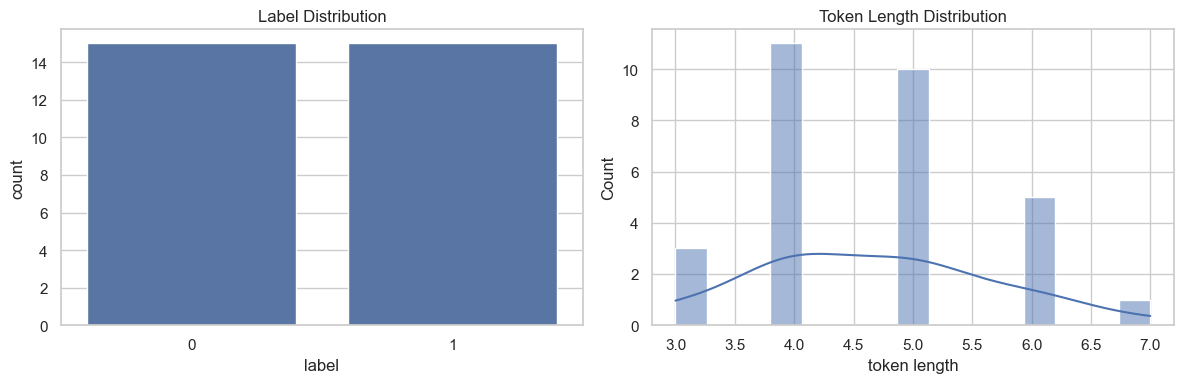

,text,tokens,token_len,label
0,정말 재미있고 다시 보고 싶은 영화였다,"[정말, 재미있고, 다시, 보고, 싶은, 영화였다]",6,1
1,배우 연기가 너무 좋고 몰입감이 뛰어났다,"[배우, 연기가, 너무, 좋고, 몰입감이, 뛰어났다]",6,1
2,스토리가 탄탄해서 시간 가는 줄 몰랐다,"[스토리가, 탄탄해서, 시간, 가는, 줄, 몰랐다]",6,1
3,기대보다 훨씬 감동적이었다,"[기대보다, 훨씬, 감동적이었다]",3,1
4,음악과 연출이 아름다웠다,"[음악과, 연출이, 아름다웠다]",3,1


In [30]:
df['clean_text'] = df['text'].astype(str).apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize_korean)
df['token_len'] = df['tokens'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='label', ax=axes[0])
axes[0].set_title('Label Distribution')

sns.histplot(df['token_len'], bins=15, kde=True, ax=axes[1])
axes[1].set_title('Token Length Distribution')
axes[1].set_xlabel('token length')

plt.tight_layout()
plt.show()

display(df[['text', 'tokens', 'token_len', 'label']].head())


## 6. Train / Valid / Test 분할

In [31]:
train_df, test_df = train_test_split(
    df[['clean_text', 'label']],
    test_size=0.2,
    stratify=df['label'],
    random_state=RANDOM_STATE
)
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.25,
    stratify=train_df['label'],
    random_state=RANDOM_STATE
)

print('train:', train_df.shape)
print('valid:', valid_df.shape)
print('test :', test_df.shape)


train: (18, 2)
valid: (6, 2)
test : (6, 2)


## 7. TextVectorization으로 수치화 준비

- 10주차 실습에서는 복잡한 subword tokenizer 대신, 기본적인 sequence화 흐름을 먼저 익힌다.
- token list를 다시 공백으로 join해서 간단한 vocabulary를 만든다.


In [32]:
train_texts = train_df['clean_text'].apply(lambda x: ' '.join(tokenize_korean(x))).tolist()
valid_texts = valid_df['clean_text'].apply(lambda x: ' '.join(tokenize_korean(x))).tolist()
test_texts = test_df['clean_text'].apply(lambda x: ' '.join(tokenize_korean(x))).tolist()

train_labels = train_df['label'].astype('int32').to_numpy()
valid_labels = valid_df['label'].astype('int32').to_numpy()
test_labels = test_df['label'].astype('int32').to_numpy()

max_tokens = 3000
sequence_length = 30

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)
vectorizer.adapt(train_texts)

sample_vector = vectorizer([train_texts[0]])
print('sample text :', train_texts[0])
print('sample vector:', sample_vector.numpy()[0][:20])


sample text : 너무 지루해서 중간에 끄고 싶었다
sample vector: [ 2 21 23 71 42  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


## 8. tf.data Dataset 만들기

In [33]:
batch_size = 16

def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=RANDOM_STATE)
    ds = ds.batch(batch_size)
    ds = ds.map(lambda x, y: (vectorizer(x), y))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_texts, train_labels, shuffle=True)
valid_ds = make_dataset(valid_texts, valid_labels)
test_ds = make_dataset(test_texts, test_labels)


## 9. LSTM baseline 모델 정의

In [34]:
embedding_dim = 64

lstm_model = keras.Sequential([
    layers.Input(shape=(sequence_length,)),
    layers.Embedding(max_tokens, embedding_dim),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,889 (851.13 KB)

 Trainable params: 217,889 (851.13 KB)

 Non-trainable params: 0 (0.00 B)

## 10. LSTM baseline 학습

In [35]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/8
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5625 - loss: 0.6934WARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x1268207c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.5556 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4444 - loss: 0.6922 - val_accuracy: 0

## 11. Text CNN baseline 모델 정의

- 과제 4와 연결되도록 간단한 Text CNN도 같이 본다.


In [36]:
cnn_model = keras.Sequential([
    layers.Input(shape=(sequence_length,)),
    layers.Embedding(max_tokens, embedding_dim),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 64)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,409 (802.38 KB)

 Trainable params: 205,409 (802.38 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Text CNN baseline 학습

In [37]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4444 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6667 - loss: 0.6872 - val_accuracy: 0.5000 - val_loss: 0.6965


## 13. Loss / Accuracy Curve 비교

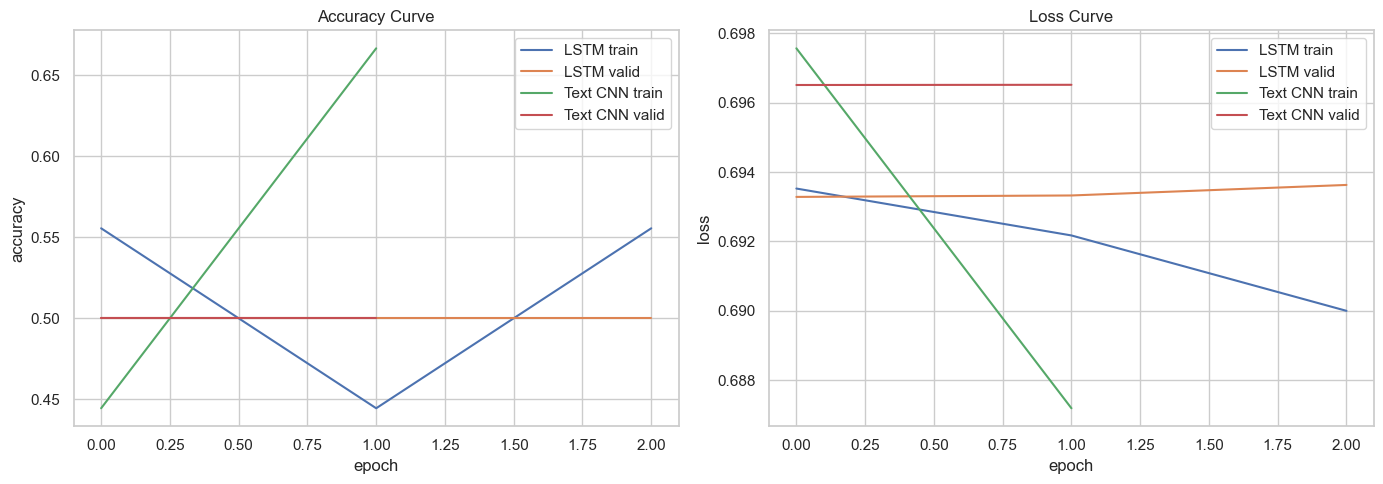

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['accuracy'], label='LSTM train')
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM valid')
axes[0].plot(history_cnn.history['accuracy'], label='Text CNN train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Text CNN valid')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='LSTM train')
axes[1].plot(history_lstm.history['val_loss'], label='LSTM valid')
axes[1].plot(history_cnn.history['loss'], label='Text CNN train')
axes[1].plot(history_cnn.history['val_loss'], label='Text CNN valid')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 14. 평가 함수 정의

In [39]:
def evaluate_binary_text_model(model, dataset, y_true, model_name):
    prob = model.predict(dataset, verbose=0).reshape(-1)
    pred = (prob >= 0.5).astype(int)
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, pred)
    }, pred


## 15. Valid / Test 성능 비교

In [40]:
valid_lstm_result, valid_lstm_pred = evaluate_binary_text_model(lstm_model, valid_ds, valid_labels, 'LSTM valid')
test_lstm_result, test_lstm_pred = evaluate_binary_text_model(lstm_model, test_ds, test_labels, 'LSTM test')
valid_cnn_result, valid_cnn_pred = evaluate_binary_text_model(cnn_model, valid_ds, valid_labels, 'Text CNN valid')
test_cnn_result, test_cnn_pred = evaluate_binary_text_model(cnn_model, test_ds, test_labels, 'Text CNN test')

comparison_df = pd.DataFrame([
    valid_lstm_result,
    test_lstm_result,
    valid_cnn_result,
    test_cnn_result
])
comparison_df.style.format({'accuracy': '{:.4f}'})


,model,accuracy
0,LSTM valid,0.5000
1,LSTM test,0.5000
2,Text CNN valid,0.5000
3,Text CNN test,0.5000


## 16. 예측 예시 확인

In [41]:
example_df = test_df.reset_index(drop=True).copy()
example_df['lstm_pred'] = test_lstm_pred
example_df['cnn_pred'] = test_cnn_pred
display(example_df.head(10))

print('[LSTM classification report]')
print(classification_report(test_labels, test_lstm_pred))

print('[Text CNN classification report]')
print(classification_report(test_labels, test_cnn_pred))


,clean_text,label,lstm_pred,cnn_pred
0,전체적으로 완성도가 높은 작품이다,1,0,0
1,결말이 허무해서 아쉬움이 컸다,0,0,0
2,메시지가 분명하고 연출도 좋았다,1,0,0
3,기대가 컸는데 실망스러웠다,0,0,0
4,스토리가 탄탄해서 시간 가는 줄 몰랐다,1,0,0
5,긴장감이 부족하고 너무 평범했다,0,0,0


[LSTM classification report]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6

[Text CNN classification report]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



## 17. Optional — Hugging Face Korean BERT Fine-tuning

- 아래 섹션은 **선택 실습**이다.
- `"transformers<5"`와 `tf-keras` 설치, pretrained model 다운로드가 가능할 때만 진행한다.
- `konlpy`가 없어도 이 섹션은 별도로 진행 가능하다.
- 즉, **KoNLPy 설치 실패와 BERT 실습 가능 여부는 별개**다.
- 목적은 LSTM / Text CNN baseline 위에 **pretrained Korean BERT fine-tuning**이 어떻게 붙는지 보는 것이다.


In [42]:
bert_ready = TRANSFORMERS_AVAILABLE
bert_model_name = 'klue/bert-base'
bert_model_candidates = [
    'klue/bert-base',
    'bert-base-multilingual-cased',
]

if not TRANSFORMERS_AVAILABLE:
    print('BERT optional section is disabled.')
    print('transformers import failed:', TRANSFORMERS_IMPORT_ERROR)
    print('현재 환경에서는 보통 transformers 5.x 또는 tf-keras 미설치가 원인입니다.')
    print('권장 해결: uv add "transformers<5" tf-keras')
    print('이 섹션은 konlpy와 무관하게 별도로 실행할 수 있습니다.')
else:
    print('BERT optional section is enabled.')
    print('primary model name:', bert_model_name)
    print('fallback model candidates:', bert_model_candidates)


BERT optional section is enabled.
primary model name: klue/bert-base
fallback model candidates: ['klue/bert-base', 'bert-base-multilingual-cased']


## 18. BERT용 데이터 소규모 샘플링

- 40분 실습 시간을 고려해서 BERT는 전체 데이터가 아니라 작은 subset으로 돌린다.
- 수업 목적은 최고 성능이 아니라 **fine-tuning workflow**를 보는 것이다.


In [43]:
bert_train_texts = train_df['clean_text'].tolist()[: min(200, len(train_df))]
bert_valid_texts = valid_df['clean_text'].tolist()[: min(60, len(valid_df))]
bert_test_texts = test_df['clean_text'].tolist()[: min(60, len(test_df))]

bert_train_labels = train_df['label'].astype('int32').to_numpy()[: len(bert_train_texts)]
bert_valid_labels = valid_df['label'].astype('int32').to_numpy()[: len(bert_valid_texts)]
bert_test_labels = test_df['label'].astype('int32').to_numpy()[: len(bert_test_texts)]

print('bert_train size:', len(bert_train_texts))
print('bert_valid size:', len(bert_valid_texts))
print('bert_test size :', len(bert_test_texts))


bert_train size: 18
bert_valid size: 6
bert_test size : 6


## 19. Tokenizer / Model 로드

In [44]:
bert_tokenizer = None
bert_model = None
bert_load_errors = []

if bert_ready:
    load_strategies = [
        ('direct_tf', dict(num_labels=2)),
        ('direct_tf_no_safetensors', dict(num_labels=2, use_safetensors=False)),
        ('from_pt_ignore_mismatch', dict(num_labels=2, from_pt=True, ignore_mismatched_sizes=True)),
        ('from_pt_no_safetensors', dict(num_labels=2, from_pt=True, ignore_mismatched_sizes=True, use_safetensors=False)),
    ]

    for candidate_model_name in bert_model_candidates:
        print(f'\nTrying BERT model candidate: {candidate_model_name}')
        try:
            candidate_tokenizer = AutoTokenizer.from_pretrained(candidate_model_name)
        except Exception as tokenizer_error:
            bert_load_errors.append((candidate_model_name, 'tokenizer', f'{type(tokenizer_error).__name__}: {tokenizer_error}'))
            continue

        for strategy_name, strategy_kwargs in load_strategies:
            try:
                print(f'Trying BERT load strategy: {strategy_name}')
                candidate_model = TFAutoModelForSequenceClassification.from_pretrained(
                    candidate_model_name,
                    **strategy_kwargs,
                )
                bert_tokenizer = candidate_tokenizer
                bert_model = candidate_model
                bert_model_name = candidate_model_name
                print(f'BERT tokenizer/model loaded successfully: {candidate_model_name} / {strategy_name}')
                break
            except Exception as strategy_error:
                bert_load_errors.append((candidate_model_name, strategy_name, f'{type(strategy_error).__name__}: {strategy_error}'))

        if bert_model is not None:
            break

    if bert_model is None:
        bert_ready = False
        print('\nBERT tokenizer/model 로드에 실패했습니다.')
        print('이 경우는 네트워크 문제보다 TF model weight 로딩 방식 또는 safetensors 호환 이슈일 가능성이 큽니다.')
        print('시도한 모델/로드 전략별 실패 기록:')
        for candidate_model_name, strategy_name, strategy_msg in bert_load_errors:
            print(f'- {candidate_model_name} / {strategy_name}: {strategy_msg}')



Trying BERT model candidate: klue/bert-base
Trying BERT load strategy: direct_tf
Trying BERT load strategy: direct_tf_no_safetensors
Trying BERT load strategy: from_pt_ignore_mismatch


Loading a PyTorch model in TensorFlow, requires both PyTorch and TensorFlow to be installed. Please see https://pytorch.org/ and https://www.tensorflow.org/install/ for installation instructions.


Trying BERT load strategy: from_pt_no_safetensors


Loading a PyTorch model in TensorFlow, requires both PyTorch and TensorFlow to be installed. Please see https://pytorch.org/ and https://www.tensorflow.org/install/ for installation instructions.



Trying BERT model candidate: bert-base-multilingual-cased
Trying BERT load strategy: direct_tf
Trying BERT load strategy: direct_tf_no_safetensors


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT tokenizer/model loaded successfully: bert-base-multilingual-cased / direct_tf_no_safetensors


## 20. BERT 입력 인코딩

In [45]:
if bert_ready:
    bert_train_enc = bert_tokenizer(bert_train_texts, truncation=True, padding=True, max_length=64, return_tensors='tf')
    bert_valid_enc = bert_tokenizer(bert_valid_texts, truncation=True, padding=True, max_length=64, return_tensors='tf')
    bert_test_enc = bert_tokenizer(bert_test_texts, truncation=True, padding=True, max_length=64, return_tensors='tf')

    print('input_ids shape:', bert_train_enc['input_ids'].shape)
    print('attention_mask shape:', bert_train_enc['attention_mask'].shape)
else:
    print('BERT section skipped.')


input_ids shape: (18, 18)
attention_mask shape: (18, 18)


## 21. BERT tf.data Dataset 만들기

In [46]:
if bert_ready:
    bert_batch_size = 8

    bert_train_ds = tf.data.Dataset.from_tensor_slices((dict(bert_train_enc), bert_train_labels)).batch(bert_batch_size)
    bert_valid_ds = tf.data.Dataset.from_tensor_slices((dict(bert_valid_enc), bert_valid_labels)).batch(bert_batch_size)
    bert_test_ds = tf.data.Dataset.from_tensor_slices((dict(bert_test_enc), bert_test_labels)).batch(bert_batch_size)
    print('BERT datasets created.')
else:
    print('BERT section skipped.')


BERT datasets created.


## 22. BERT Fine-tuning

- Hugging Face TensorFlow 모델은 내부적으로 `tf_keras` 기반이다.
- 따라서 BERT compile 단계에서는 `keras 3` 객체가 아니라 `tf_keras` optimizer/loss를 사용한다.

In [47]:
history_bert = None

if bert_ready:
    bert_model.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=2e-5),
        loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    history_bert = bert_model.fit(
        bert_train_ds,
        validation_data=bert_valid_ds,
        epochs=1,
        verbose=1
    )
else:
    print('BERT section skipped.')


3/3 [==============================] - 12s 791ms/step - loss: 0.7214 - accuracy: 0.5000 - val_loss: 0.7041 - val_accuracy: 0.3333


## 23. BERT 결과 간단 확인

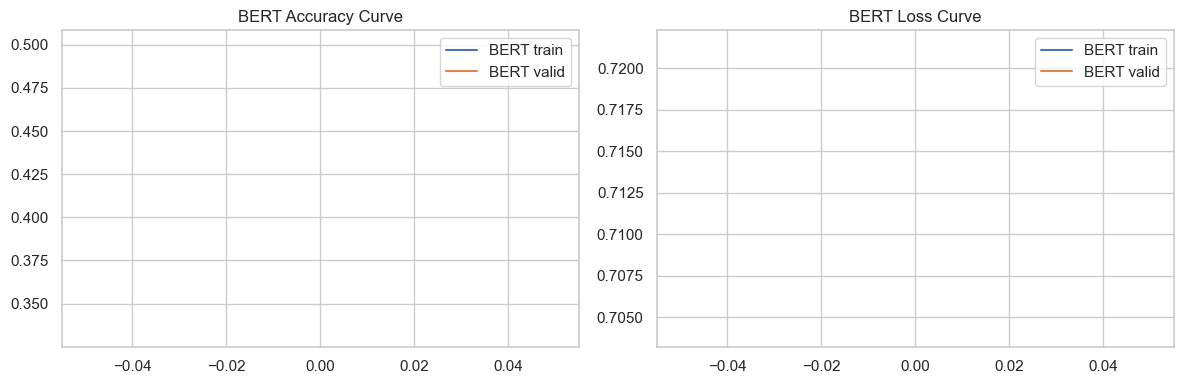

,model,accuracy
0,BERT valid,0.3333
1,BERT test,0.5000


In [49]:
if bert_ready and history_bert is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_bert.history['accuracy'], label='BERT train')
    axes[0].plot(history_bert.history['val_accuracy'], label='BERT valid')
    axes[0].set_title('BERT Accuracy Curve')
    axes[0].legend()

    axes[1].plot(history_bert.history['loss'], label='BERT train')
    axes[1].plot(history_bert.history['val_loss'], label='BERT valid')
    axes[1].set_title('BERT Loss Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    bert_valid_logits = bert_model.predict(bert_valid_ds, verbose=0).logits
    bert_test_logits = bert_model.predict(bert_test_ds, verbose=0).logits
    bert_valid_pred = np.argmax(bert_valid_logits, axis=1)
    bert_test_pred = np.argmax(bert_test_logits, axis=1)

    bert_compare_df = pd.DataFrame([
        {'model': 'BERT valid', 'accuracy': accuracy_score(bert_valid_labels, bert_valid_pred)},
        {'model': 'BERT test', 'accuracy': accuracy_score(bert_test_labels, bert_test_pred)}
    ])
    display(bert_compare_df.style.format({'accuracy': '{:.4f}'}))
else:
    print('BERT section skipped.')


## 24. Transformer로 어떻게 확장되는가

- 위 optional BERT 섹션까지 진행했다면, **tokenizer + pretrained backbone + fine-tuning** 흐름을 직접 본 것이다.
- 진행하지 못했더라도 이번 실습의 기본 루프 위에 BERT fine-tuning이 얹힌다는 구조만 이해하면 충분하다.
- 특히 이번 노트북은 **KoNLPy 없이도 기본 실습과 BERT optional 실습을 분리해서 수행할 수 있게** 구성되어 있다.
- 실제 프로젝트에서는 여기서 더 큰 데이터, 더 긴 학습, 더 정교한 preprocessing과 evaluation으로 확장된다.


## 25. 실습 해석 가이드

### 확인할 포인트
1. 형태소 분석 결과가 공백 단위와 어떻게 달랐는가?
2. sequence 길이 분포를 보고 padding 길이를 왜 조절해야 하는가?
3. LSTM과 Text CNN은 어떤 학습 곡선 차이를 보였는가?
4. optional BERT까지 돌렸다면 pretrained model은 무엇이 달랐는가?
5. 감성 분석에서 부정 표현과 반전 표현은 왜 어려운가?
6. 여기서 Transformer fine-tuning으로 넘어가면 무엇이 더 좋아질 수 있는가?

### 한 줄 정리
- **텍스트는 sequence로 다뤄야 하고, Attention / Transformer는 그 sequence 문맥을 더 직접적으로 읽게 만든다.**
